# [EDA] 고객 단위 집계 피처 탐색 — 2026-06-29

**목적**: `run_customer_pipeline.py`로 생성된 집계 테이블을 탐색한다.

**입력 파일**:
- `data/processed/customer_features_all_customers.csv` — 전체 고객 (20,000명)
- `data/processed/customer_features_us_customers.csv` — US 고객 (3,648명)

**분석 항목**:
1. 기본 검사 (shape, dtypes, null, duplicates)
2. 수치형 피처 분포 (recency, count, spend)
3. 카테고리 피처 분포 (top_view_category, top_purchase_category)
4. 전체 vs US 비교

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns

# 한국어 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# [VS Code]
DATA_DIR = '../data/processed'
INTERIM_DIR = "../data/interim"

# [Colab] Colab에서 실행 시 위 DATA_DIR 주석 처리 후 아래 두 줄 주석 해제
# from google.colab import drive; drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/why-they-leave/retail-clickstream-analysis/processed'

In [2]:
df_all = pd.read_csv(f'{DATA_DIR}/customer_features_all_customers.csv')
df_us  = pd.read_csv(f'{DATA_DIR}/customer_features_us_customers.csv')

print(f'전체: {df_all.shape}  |  US-only: {df_us.shape}')

전체: (20000, 11)  |  US-only: (3648, 11)


## 1. 기본 검사

In [3]:
df_all.dtypes

customer_id                int64
recency_session_days     float64
recency_order_days       float64
session_count              int64
page_view_count            int64
add_to_cart_count          int64
order_count                int64
total_spend              float64
avg_order_value          float64
top_view_category            str
top_purchase_category        str
dtype: object

In [4]:
# 결측치 비율
null_rate = df_all.isna().mean().round(3) * 100
null_rate.to_frame('null_%')

,null_%
customer_id,0.0
recency_session_days,0.3
recency_order_days,18.7
session_count,0.0
page_view_count,0.0
add_to_cart_count,0.0
order_count,0.0
total_spend,0.0
avg_order_value,18.7
top_view_category,0.3


In [5]:
# customer_id 중복 확인
print('전체 중복:', df_all['customer_id'].duplicated().sum())
print('US 중복:  ', df_us['customer_id'].duplicated().sum())

전체 중복: 0
US 중복:   0


In [6]:
df_all.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,20000.0,10000.500000,5773.647028,1.0,5000.7500,10000.5000,15000.250000,20000.0
recency_session_days,19945.0,350.558536,341.303469,0.0,99.0000,243.0000,490.000000,2119.0
recency_order_days,16268.0,775.365810,573.037174,0.0,285.0000,660.0000,1191.000000,2130.0
session_count,20000.0,6.000000,2.468219,0.0,4.0000,6.0000,8.000000,17.0
page_view_count,20000.0,26.967150,12.370898,0.0,18.0000,26.0000,35.000000,85.0
add_to_cart_count,20000.0,7.156300,4.020271,0.0,4.0000,7.0000,10.000000,28.0
order_count,20000.0,1.679000,1.292959,0.0,1.0000,2.0000,2.000000,9.0
total_spend,20000.0,500.010890,715.637229,0.0,34.8275,232.2600,680.582500,9623.8
avg_order_value,16268.0,298.993407,379.520178,2.8,78.9300,185.6975,380.375833,9623.8


## 2. 수치형 피처 분포

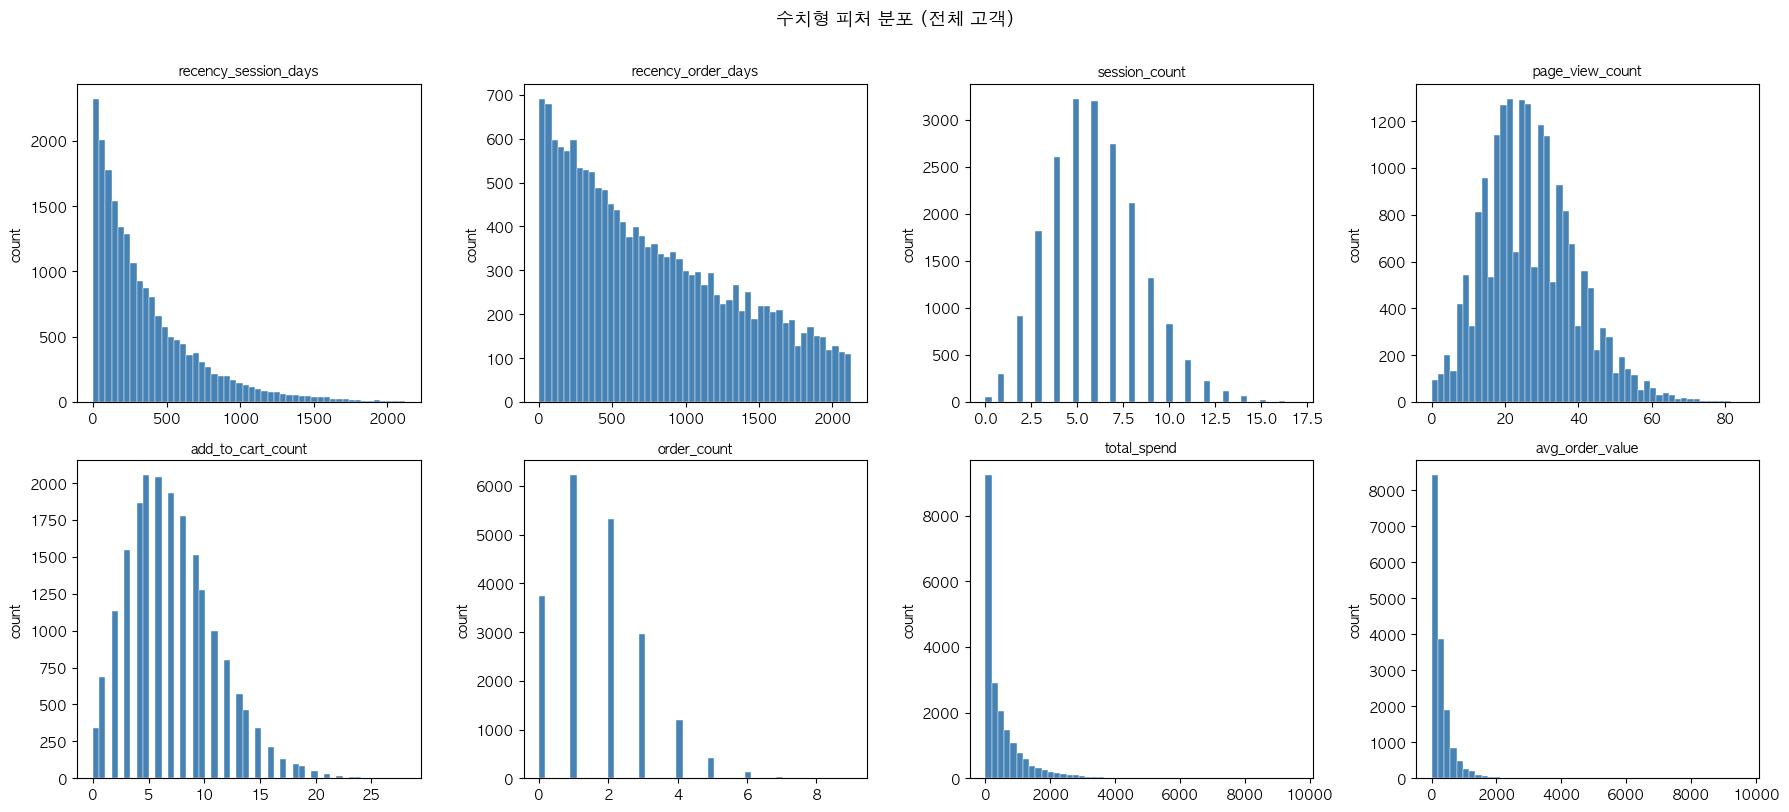

In [7]:
num_cols = [
    'recency_session_days', 'recency_order_days',
    'session_count', 'page_view_count', 'add_to_cart_count',
    'order_count', 'total_spend', 'avg_order_value'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df_all[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')

plt.suptitle('수치형 피처 분포 (전체 고객)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# 주문 없는 고객 비율
no_order_rate = (df_all['order_count'] == 0).mean() * 100
no_session_rate = (df_all['session_count'] == 0).mean() * 100
print(f'주문 없는 고객: {no_order_rate:.1f}%')
print(f'세션 없는 고객: {no_session_rate:.1f}%')

주문 없는 고객: 18.7%
세션 없는 고객: 0.3%


## 3. 카테고리 피처 분포

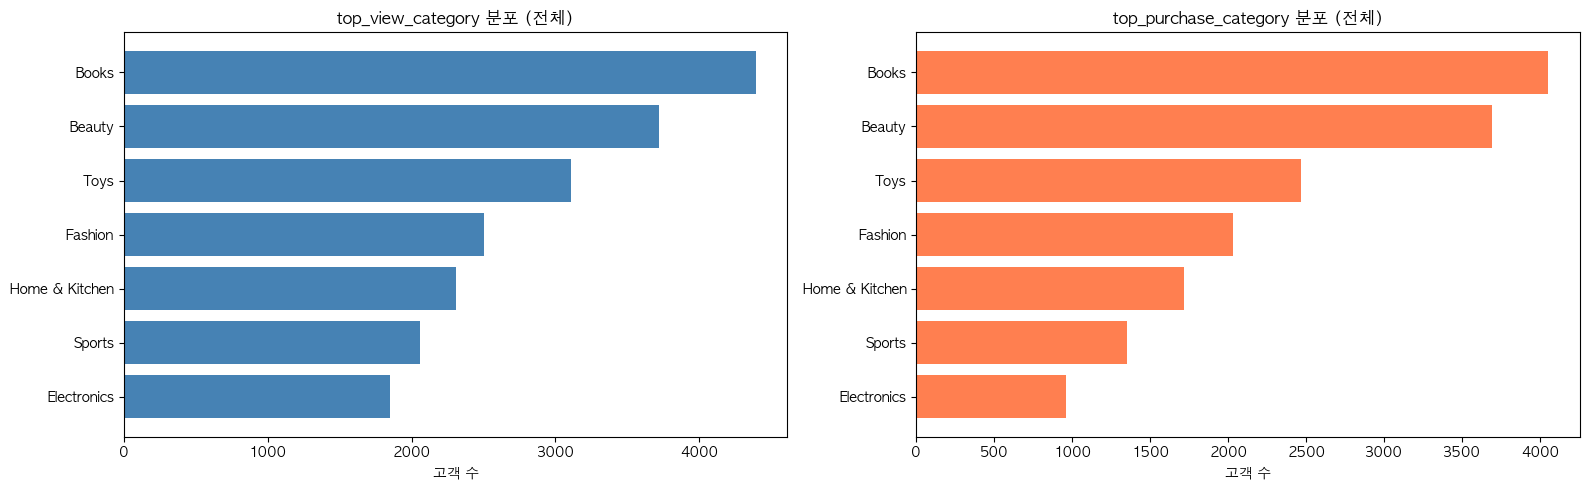

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# top_view_category
view_counts = df_all['top_view_category'].value_counts()
axes[0].barh(view_counts.index, view_counts.values, color='steelblue')
axes[0].set_title('top_view_category 분포 (전체)')
axes[0].set_xlabel('고객 수')
axes[0].invert_yaxis()

# top_purchase_category
purchase_counts = df_all['top_purchase_category'].value_counts()
axes[1].barh(purchase_counts.index, purchase_counts.values, color='coral')
axes[1].set_title('top_purchase_category 분포 (전체)')
axes[1].set_xlabel('고객 수')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
# 조회 vs 구매 카테고리 일치율
both = df_all.dropna(subset=['top_view_category', 'top_purchase_category'])
match_rate = (both['top_view_category'] == both['top_purchase_category']).mean() * 100
print(f'조회 카테고리 == 구매 카테고리 일치율: {match_rate:.1f}%')

조회 카테고리 == 구매 카테고리 일치율: 38.1%


## 4. 전체 vs US 비교

In [11]:
compare_cols = ['session_count', 'page_view_count', 'order_count', 'total_spend', 'avg_order_value']

comparison = pd.DataFrame({
    '전체 (mean)': df_all[compare_cols].mean(),
    'US (mean)':   df_us[compare_cols].mean(),
    '전체 (median)': df_all[compare_cols].median(),
    'US (median)':   df_us[compare_cols].median(),
}).round(2)

comparison

,전체 (mean),US (mean),전체 (median),US (median)
session_count,6.00,6.01,6.00,6.00
page_view_count,26.97,26.96,26.00,26.00
order_count,1.68,1.68,2.00,1.00
total_spend,500.01,500.86,232.26,229.01
avg_order_value,298.99,297.71,185.70,184.02


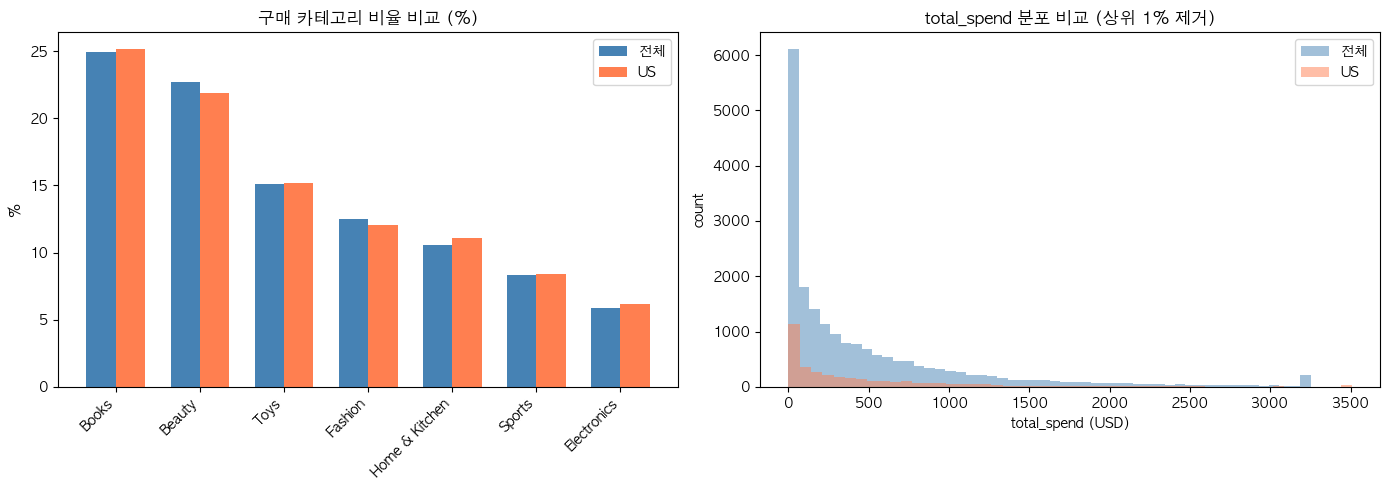

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# top_purchase_category 전체 vs US 비교
all_cat = df_all['top_purchase_category'].value_counts(normalize=True) * 100
us_cat  = df_us['top_purchase_category'].value_counts(normalize=True) * 100

cats = all_cat.index.tolist()
x = np.arange(len(cats))
w = 0.35

axes[0].bar(x - w/2, all_cat.reindex(cats).fillna(0), w, label='전체', color='steelblue')
axes[0].bar(x + w/2, us_cat.reindex(cats).fillna(0),  w, label='US',   color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cats, rotation=45, ha='right')
axes[0].set_title('구매 카테고리 비율 비교 (%)')
axes[0].set_ylabel('%')
axes[0].legend()

# total_spend 분포 비교
axes[1].hist(df_all['total_spend'].clip(upper=df_all['total_spend'].quantile(0.99)),
             bins=50, alpha=0.5, label='전체', color='steelblue')
axes[1].hist(df_us['total_spend'].clip(upper=df_us['total_spend'].quantile(0.99)),
             bins=50, alpha=0.5, label='US',   color='coral')
axes[1].set_title('total_spend 분포 비교 (상위 1% 제거)')
axes[1].set_xlabel('total_spend (USD)')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. 파생  피처 만들기
- 집계 테이블의 피처가 세그먼트를 만들기에는 크기/횟수 중심이기 때문에 고객의 행동 성향을 더 잘 파악하기 위함. 
- 고객 집계 피처에서 세그먼트 구분에 더 직접적으로 쓸 수 있는 행동 비율/플래그/변환 피처 추가 

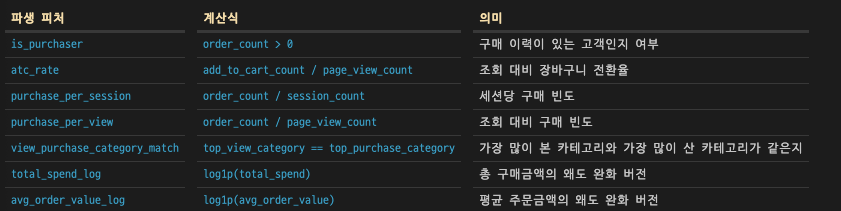

In [13]:
def add_segment_candidate_features(df: pd.DataFrame) -> pd.DataFrame:
  df = df.copy()

  # 구매 이력이 있는 고객인지 여부
  df["is_purchaser"] = (df["order_count"] > 0).astype(int)  
  
  # 조회한 것 대비 장바구니에 얼마나 담았는지 
  df["atc_rate"] = np.where( 
    df["page_view_count"] > 0,
    df["add_to_cart_count"] / df["page_view_count"], 
    np.nan,
  )

  # 방문 세션 당 구매가 얼마나 발생했는지 
  df["purchase_per_session"] = np.where(
    df["session_count"] > 0,
    df["order_count"] / df["session_count"], 
    np.nan,
  )

  # 조회 대비 구매 빈도
  # 주의: order_count는 주문 수이고, page_view_count는 상품 대비 조회 이벤트 수라 단위가 완전히 같지 않음.
  # 정확한 구매 전환율이라고 이해 x, 탐색 대비 구매 성향 지표로 이해. 
  df["purchase_per_view"] = np.where(
    df["page_view_count"] > 0,
    df["order_count"] / df["page_view_count"], 
    np.nan,
  )

  # 가장 많이 본 카테고리랑 가장 많이 구매한 카테고리가 같은지
  view_notna = df["top_view_category"].notna()
  purchase_notna = df["top_purchase_category"].notna()
  category_same = df["top_view_category"].astype("string").eq(
    df["top_purchase_category"].astype("string")
  )

  df["view_purchase_category_match"] = (
    view_notna & purchase_notna & category_same
  ).astype(int)

  # 클러스터링에서 해당 피처가 과하게 지배하는 것 방지하기 위해 로그 변환 
  df["total_spend_log"] = np.log1p(df["total_spend"])
  df["avg_order_value_log"] = np.log1p(df["avg_order_value"])

  return df


In [14]:
df_all2 = add_segment_candidate_features(df_all)
df_us2 = add_segment_candidate_features(df_us)

In [15]:
candidate_cols = [
  "session_count",
  "page_view_count",
  "add_to_cart_count",
  "atc_rate",
  "is_purchaser",
  "order_count",
  "purchase_per_session",
  "purchase_per_view",
  "avg_order_value",
  "avg_order_value_log",
  "recency_session_days",
  "recency_order_days",
  "view_purchase_category_match",
  "total_spend",
  "total_spend_log"
]

In [16]:
display(df_all2[candidate_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
session_count,20000.0,6.000000,2.468219,0.000000,4.000000,6.000000,8.000000,17.000000
page_view_count,20000.0,26.967150,12.370898,0.000000,18.000000,26.000000,35.000000,85.000000
add_to_cart_count,20000.0,7.156300,4.020271,0.000000,4.000000,7.000000,10.000000,28.000000
atc_rate,19945.0,0.265349,0.100777,0.000000,0.200000,0.260870,0.325000,1.000000
is_purchaser,20000.0,0.813400,0.389600,0.000000,1.000000,1.000000,1.000000,1.000000
order_count,20000.0,1.679000,1.292959,0.000000,1.000000,2.000000,2.000000,9.000000
purchase_per_session,19945.0,0.280389,0.204228,0.000000,0.142857,0.250000,0.400000,1.000000
purchase_per_view,19945.0,0.063802,0.049836,0.000000,0.032258,0.058824,0.090909,1.000000
avg_order_value,16268.0,298.993407,379.520178,2.800000,78.930000,185.697500,380.375833,9623.800000
avg_order_value_log,16268.0,5.124440,1.149396,1.335001,4.381151,5.229490,5.943785,9.172098


[해석 시 고려해볼 수 있는 것들]
- mean과 median의 차이가 크면 분포가 치우쳤다고 볼 수 있음. 
- max가 너무 크다면 이상치를 고려할 수 있음 
- std가 크다면 고객 간 차이를 잘 구분할 가능성 있음
- 값이 0이거나 변동이 작으면 세그먼트로서의 구분력이 낮을 수 있음

describe로 확인했을 떄, 
- total_spend, avg_order_value는 log 버전을 쓰는게 더 적합하다고 생각함.
- 위의 주석에서도 언급했듯이, purchase_per_view는 order_count / page_view_count 라서 실제 상품 단위 전환율이 아니라 그냥 보류하는게 나을 것 같음. 


In [17]:
# 결측치 확인
missing = (
  df_all2[candidate_cols + ["top_view_category", "top_purchase_category"]]
  .isna()
  .mean()
  .mul(100)
  .sort_values(ascending=False)
  .reset_index()
)

missing.columns = ["column", "missing_pct"]

display(missing)

,column,missing_pct
0,avg_order_value,18.660
1,avg_order_value_log,18.660
2,recency_order_days,18.660
3,top_purchase_category,18.660
4,purchase_per_session,0.275
5,purchase_per_view,0.275
6,atc_rate,0.275
7,recency_session_days,0.275
8,top_view_category,0.275
9,is_purchaser,0.000


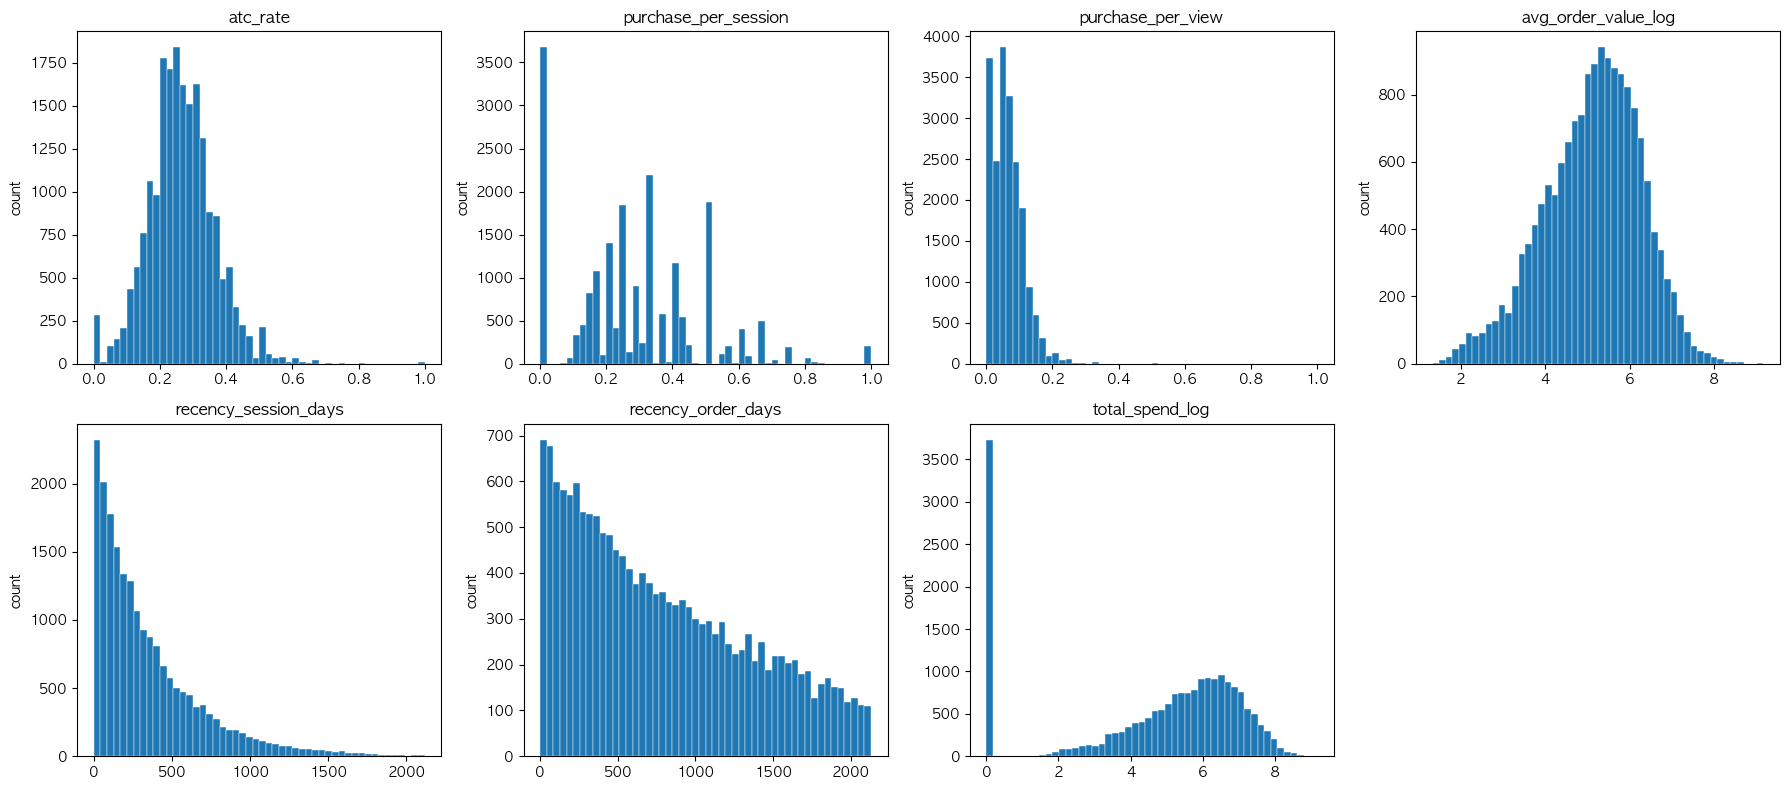

In [18]:
# 파생 피처 분포 시각화 

plot_cols = [
  "atc_rate",
  "purchase_per_session",
  "purchase_per_view",
  "avg_order_value_log",
  "recency_session_days",
  "recency_order_days",
  "total_spend_log"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
  data = df_all2[col].dropna()
  axes[i].hist(data, bins=50, edgecolor='white', linewidth=0.3)
  axes[i].set_title(col)
  axes[i].set_xlabel("")
  axes[i].set_ylabel("count")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

  atc_rate

  - 평균 0.265, 중앙값 0.261
  - 분포가 0.2~0.35 근처에 모여 있습니다.
  - 고객 간 차이가 꽤 있어서 탐색형 vs 장바구니 의도형을 나누는 피처로 쓸 만합니다.
  - 다만 max가 1.0이라 page view가 적은 고객에서 비율이 튀는 케이스는 clip이 필요할 수 있습니다.

  purchase_per_session

  - 평균 0.280, 중앙값 0.25
  - 0에 큰 spike가 있습니다. 이건 미구매자 때문입니다.
  - 구매자/미구매자를 강하게 나누는 피처라서 유용하지만, is_purchaser와 정보가 겹칩니다.
  - 세그먼트에 넣을 때는 is_purchaser와 같이 해석해야 합니다.

  purchase_per_view

  - 평균 0.064, 중앙값 0.059
  - 대부분 낮은 값에 몰려 있습니다.
  - “조회 대비 구매 성향”으로는 참고 가능하지만, order_count / page_view_count라 단위가 애매합니다.
  - 보류 피처로 두는 게 맞아 보입니다.

  avg_order_value_log

  - 원본 avg_order_value는 max가 9623.8로 크지만, log 변환 후에는 분포가 훨씬 안정적입니다.
  - 객단가 피처를 쓸 거면 원본보다 avg_order_value_log 사용이 적절합니다.

  total_spend_log

  - 0에 큰 spike가 있습니다. 미구매자 total_spend = 0 때문입니다.
  - 구매자 내부에서는 적당히 퍼져 있어서 구매 규모 피처로 쓸 만합니다.
  - 단, is_purchaser와 함께 써야 합니다.

  recency_session_days

  - 오른쪽 꼬리가 긴 분포입니다.
  - 최근 방문 고객이 많고, 오래전에 방문한 고객이 소수 있습니다.
  - 그대로 쓰기보다 scaling 또는 bucket화가 좋아 보입니다.

  recency_order_days

  - 구매자 기준으로 넓게 퍼져 있습니다.
  - 구매 시점의 최근성 구분에 유용합니다.
  - 미구매자는 결측이므로 missing flag 또는 별도 처리 필요합니다.

In [19]:
# 구매자 vs 비구매자 비교
buyer_compare_cols = [
  "session_count",
  "page_view_count",
  "add_to_cart_count",
  "atc_rate",
  "recency_session_days",
  "purchase_per_session"
]

buyer_summary = (
  df_all2
  .groupby("is_purchaser")[buyer_compare_cols]
  .agg(["mean", "median", "std"])
  .T
)

display(buyer_summary)

is_purchaser                          0           1
session_count        mean      4.333601    6.382284
                     median    4.000000    6.000000
                     std       2.092069    2.388029
page_view_count      mean     18.322615   28.950270
                     median   17.000000   28.000000
                     std       9.905633   12.023610
add_to_cart_count    mean      4.228832    7.827883
                     median    4.000000    7.000000
                     std       3.097218    3.905537
atc_rate             mean      0.225126    0.274440
                     median    0.222222    0.266667
                     std       0.126033    0.091727
recency_session_days mean    465.701387  324.533194
                     median  334.000000  229.000000
                     std     431.319779  311.615949
purchase_per_session mean      0.000000    0.343764
                     median    0.000000    0.333333
                     std       0.000000    0.171317

- 구매자가 모두 더 높음. 
-> is_purchase 하나로 나누기 보다 구매자 내부에서도 저활동 구매 / 장바구니 의도형 등 이런 세부 세그먼트를 만들 필요성이 있음

In [20]:
# top 카테고리 집중도 확인
session_events = pd.read_csv(f"{INTERIM_DIR}/sessions_events_products.csv")
order_details = pd.read_csv(f"{INTERIM_DIR}/orders_items_products.csv")

print(session_events.shape)
print(order_details.shape)

display(session_events.head())
display(order_details.head())

(760958, 6)
(59163, 7)


,session_id,customer_id,start_time,event_type,product_id,category
0,1,12360,2021-12-27T00:01:36,page_view,93.0,Electronics
1,1,12360,2021-12-27T00:01:36,page_view,1005.0,Books
2,1,12360,2021-12-27T00:01:36,add_to_cart,1005.0,Books
3,1,12360,2021-12-27T00:01:36,page_view,918.0,Books
4,1,12360,2021-12-27T00:01:36,page_view,946.0,Books


,order_id,customer_id,order_time,total_usd,product_id,quantity,category
0,1,13917,2025-01-31T23:07:42,85.72,226,1,Home & Kitchen
1,2,1022,2024-02-19T01:17:50,116.17,771,1,Fashion
2,3,6145,2024-12-04T20:24:13,137.35,415,1,Beauty
3,3,6145,2024-12-04T20:24:13,137.35,24,1,Electronics
4,4,3152,2024-07-17T08:50:47,27.35,1157,1,Toys


In [21]:
def build_category_features(
    customer_features: pd.DataFrame,
    session_events: pd.DataFrame,
    order_details: pd.DataFrame,
) -> pd.DataFrame:
    base = customer_features[["customer_id"]].copy()

    # 조회 카테고리 다양성: 고객이 page_view한 서로 다른 카테고리 수
    view_events = session_events[
        (session_events["event_type"] == "page_view")
        & session_events["category"].notna()
    ].copy()

    view_diversity = (
        view_events
        .groupby("customer_id")["category"]
        .nunique()
        .rename("category_diversity_view")
        .reset_index()
    )

    # top view category 집중도: 전체 page_view 중 최다 조회 카테고리 비중
    view_cat_counts = (
        view_events
        .groupby(["customer_id", "category"])
        .size()
        .reset_index(name="view_cnt")
    )

    view_total = (
        view_cat_counts
        .groupby("customer_id")["view_cnt"]
        .sum()
        .rename("view_total")
        .reset_index()
    )

    view_top = (
        view_cat_counts
        .sort_values(["customer_id", "view_cnt", "category"], ascending=[True, False, True])
        .drop_duplicates("customer_id")
        .rename(columns={"category": "dominant_view_category"})
    )

    view_concentration = view_top.merge(view_total, on="customer_id", how="left")
    view_concentration["dominant_view_category_ratio"] = (
        view_concentration["view_cnt"] / view_concentration["view_total"]
    )

    view_concentration = view_concentration[
        ["customer_id", "dominant_view_category", "dominant_view_category_ratio"]
    ]

    # 구매 카테고리 다양성: 고객이 구매한 서로 다른 카테고리 수
    purchase_events = order_details[order_details["category"].notna()].copy()

    purchase_diversity = (
        purchase_events
        .groupby("customer_id")["category"]
        .nunique()
        .rename("category_diversity_purchase")
        .reset_index()
    )

    # 구매 수량 컬럼 자동 감지. 없으면 구매 라인 수 기준으로 집계.
    qty_col = next(
        (col for col in ["quantity", "Quantity", "qty", "Qty"] if col in purchase_events.columns),
        None,
    )
    purchase_events["_purchase_weight"] = 1 if qty_col is None else purchase_events[qty_col]

    # top purchase category 집중도: 전체 구매 수량/라인 중 최다 구매 카테고리 비중
    purchase_cat_counts = (
        purchase_events
        .groupby(["customer_id", "category"])["_purchase_weight"]
        .sum()
        .reset_index(name="purchase_qty")
    )

    purchase_total = (
        purchase_cat_counts
        .groupby("customer_id")["purchase_qty"]
        .sum()
        .rename("purchase_total_qty")
        .reset_index()
    )

    purchase_top = (
        purchase_cat_counts
        .sort_values(["customer_id", "purchase_qty", "category"], ascending=[True, False, True])
        .drop_duplicates("customer_id")
        .rename(columns={"category": "dominant_purchase_category"})
    )

    purchase_concentration = purchase_top.merge(purchase_total, on="customer_id", how="left")
    purchase_concentration["dominant_purchase_category_ratio"] = (
        purchase_concentration["purchase_qty"]
        / purchase_concentration["purchase_total_qty"]
    )

    purchase_concentration = purchase_concentration[
        ["customer_id", "dominant_purchase_category", "dominant_purchase_category_ratio"]
    ]

    result = (
        base
        .merge(view_diversity, on="customer_id", how="left")
        .merge(view_concentration, on="customer_id", how="left")
        .merge(purchase_diversity, on="customer_id", how="left")
        .merge(purchase_concentration, on="customer_id", how="left")
    )

    return result



In [22]:
cat_features_all = build_category_features(df_all2, session_events, order_details)
cat_features_us = build_category_features(df_us2, session_events, order_details)

df_all3 = df_all2.merge(cat_features_all, on="customer_id", how="left")
df_us3 = df_us2.merge(cat_features_us, on="customer_id", how="left")

category_feature_cols = [
    "category_diversity_view",
    "dominant_view_category_ratio",
    "category_diversity_purchase",
    "dominant_purchase_category_ratio",
]

display(df_all3[category_feature_cols].describe().T)



,count,mean,std,min,25%,50%,75%,max
category_diversity_view,19945.0,6.132865,1.161237,1.000000,6.000000,7.000000,7.000000,7.0
dominant_view_category_ratio,19945.0,0.345416,0.116009,0.157895,0.266667,0.319149,0.391304,1.0
category_diversity_purchase,16268.0,2.430600,1.254846,1.000000,1.000000,2.000000,3.000000,7.0
dominant_purchase_category_ratio,16268.0,0.663228,0.245194,0.142857,0.500000,0.600000,1.000000,1.0


  - 조회는 대부분 6~7개 카테고리를 넓게 봅니다.
      - category_diversity_view median이 7이라, 조회 다양성은 거의 포화되어 있습니다.
      - 그래서 이 피처는 세그먼트 구분력이 생각보다 약할 수 있습니다.

  - 조회 top category 집중도는 평균 34.5%입니다.
      - 여러 카테고리를 보긴 하지만, 가장 많이 본 카테고리가 1/3 정도를 차지합니다.
      - dominant_view_category_ratio는 “관심 집중형 vs 넓은 탐색형” 구분에 쓸 만합니다.

  - 구매 카테고리 다양성은 평균 2.43개입니다.
      - 조회보다 구매는 훨씬 좁습니다.
      - category_diversity_purchase는 세그먼트에 유용할 가능성이 큽니다.

  - 구매 top category 집중도는 평균 66.3%, 중앙값 60%입니다.
      - 구매는 특정 카테고리에 꽤 집중됩니다.
      - dominant_purchase_category_ratio는 “단일 카테고리 구매 집중형 vs 다카테고리 구매형” 구분에 좋아 보입니다.

## 7. 후보 피처 상관관계 분석

세그먼트 입력 후보 피처 간 중복도를 확인한다. 상관이 매우 높은 피처는 #16에서 clustering/rule-based segmentation에 동시에 넣을지 검토가 필요하다.


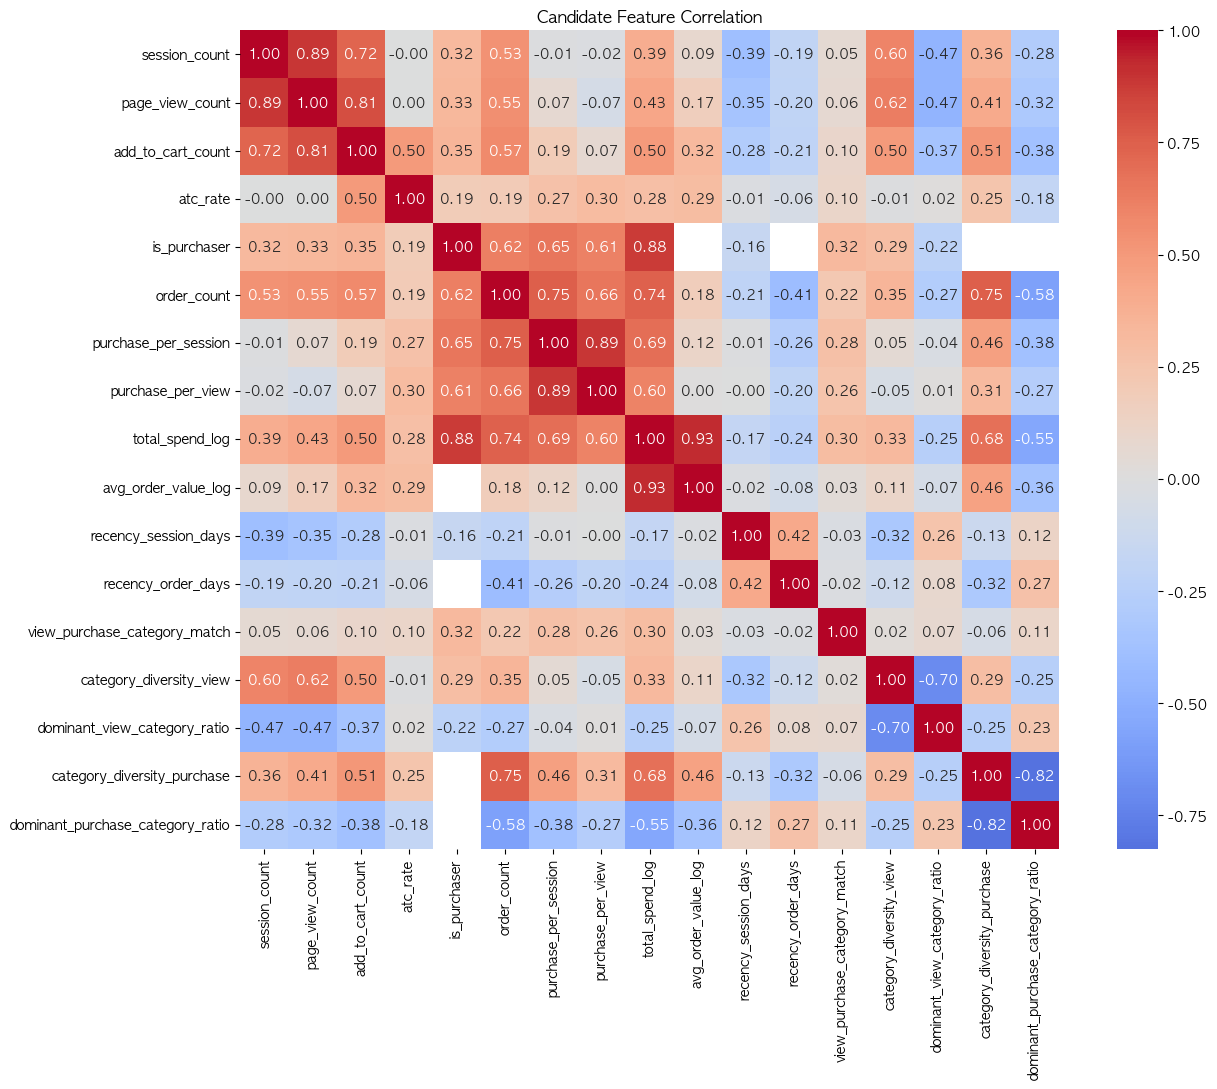

,feature_1,feature_2,corr,abs_corr
145,total_spend_log,avg_order_value_log,0.926282,0.926282
109,purchase_per_session,purchase_per_view,0.892601,0.892601
1,session_count,page_view_count,0.890877,0.890877
76,is_purchaser,total_spend_log,0.876980,0.876980
271,category_diversity_purchase,dominant_purchase_category_ratio,-0.824375,0.824375
19,page_view_count,add_to_cart_count,0.814119,0.814119
91,order_count,purchase_per_session,0.754913,0.754913
100,order_count,category_diversity_purchase,0.752382,0.752382
93,order_count,total_spend_log,0.742402,0.742402
2,session_count,add_to_cart_count,0.723423,0.723423


In [23]:
corr_cols = [
    "session_count",
    "page_view_count",
    "add_to_cart_count",
    "atc_rate",
    "is_purchaser",
    "order_count",
    "purchase_per_session",
    "purchase_per_view",
    "total_spend_log",
    "avg_order_value_log",
    "recency_session_days",
    "recency_order_days",
    "view_purchase_category_match",
    "category_diversity_view",
    "dominant_view_category_ratio",
    "category_diversity_purchase",
    "dominant_purchase_category_ratio",
]

corr = df_all3[corr_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Candidate Feature Correlation")
plt.tight_layout()
plt.show()

# 절대 상관계수 기준 상위 pair 확인
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
display(corr_pairs.sort_values("abs_corr", ascending=False).head(20))


## 8. window 피처 분포 확인

1차 v2 실험은 기존 전체 기간 누적 피처를 사용하되, 운영 반영 시 필요한 최근 30일/90일/365일 window 피처의 분포를 함께 확인한다. 기준일은 기존 고객 피처 생성과 동일하게 `2025-11-01`로 둔다.


In [45]:
ANALYSIS_DATE = pd.Timestamp("2025-11-01")

def build_window_features(
    customer_features: pd.DataFrame,
    session_events: pd.DataFrame,
    order_details: pd.DataFrame,
    analysis_date: pd.Timestamp = ANALYSIS_DATE,
) -> pd.DataFrame:
    base = customer_features[["customer_id"]].copy()
    sessions = session_events.copy()
    orders = order_details.copy()
    sessions["start_time"] = pd.to_datetime(sessions["start_time"])
    orders["order_time"] = pd.to_datetime(orders["order_time"])

    frames = [base]

    for days in [30, 90, 365]:
        since = analysis_date - pd.Timedelta(days=days)
        se = sessions[(sessions["start_time"] >= since) & (sessions["start_time"] < analysis_date)]
        od = orders[(orders["order_time"] >= since) & (orders["order_time"] < analysis_date)]

        event_counts = (
            se[se["event_type"].isin(["page_view", "add_to_cart"])]
            .groupby(["customer_id", "event_type"])
            .size()
            .unstack(fill_value=0)
            .reset_index()
            .rename(columns={
                "page_view": f"page_view_count_{days}d",
                "add_to_cart": f"add_to_cart_count_{days}d",
            })
        )
        for col in [f"page_view_count_{days}d", f"add_to_cart_count_{days}d"]:
            if col not in event_counts.columns:
                event_counts[col] = 0

        session_counts = (
            se.groupby("customer_id")["session_id"]
            .nunique()
            .rename(f"session_count_{days}d")
            .reset_index()
        )

        order_level = od.drop_duplicates(["customer_id", "order_id"])
        order_counts = (
            order_level.groupby("customer_id")
            .agg(
                **{
                    f"order_count_{days}d": ("order_id", "nunique"),
                    f"total_spend_{days}d": ("total_usd", "sum"),
                }
            )
            .reset_index()
        )

        top_view = (
            se[(se["event_type"] == "page_view") & se["category"].notna()]
            .groupby(["customer_id", "category"])
            .size()
            .reset_index(name="cnt")
            .sort_values(["customer_id", "cnt", "category"], ascending=[True, False, True])
            .drop_duplicates("customer_id")
            .rename(columns={"category": f"top_view_category_{days}d"})
            [["customer_id", f"top_view_category_{days}d"]]
        )

        top_purchase = (
            od[od["category"].notna()]
            .groupby(["customer_id", "category"])["quantity"]
            .sum()
            .reset_index(name="qty")
            .sort_values(["customer_id", "qty", "category"], ascending=[True, False, True])
            .drop_duplicates("customer_id")
            .rename(columns={"category": f"top_purchase_category_{days}d"})
            [["customer_id", f"top_purchase_category_{days}d"]]
        )

        window = (
            session_counts
            .merge(event_counts, on="customer_id", how="outer")
            .merge(order_counts, on="customer_id", how="outer")
            .merge(top_view, on="customer_id", how="outer")
            .merge(top_purchase, on="customer_id", how="outer")
        )
        frames.append(window)

    result = frames[0]
    for frame in frames[1:]:
        result = result.merge(frame, on="customer_id", how="left")

    count_cols = [c for c in result.columns if c.endswith(("_30d", "_90d", "_365d")) and not c.startswith("top_")]
    result[count_cols] = result[count_cols].fillna(0)

    for days in [30, 90, 365]:
        result[f"atc_rate_{days}d"] = np.where(
            result[f"page_view_count_{days}d"] > 0,
            result[f"add_to_cart_count_{days}d"] / result[f"page_view_count_{days}d"],
            np.nan,
        )
        result[f"purchase_per_session_{days}d"] = np.where(
            result[f"session_count_{days}d"] > 0,
            result[f"order_count_{days}d"] / result[f"session_count_{days}d"],
            np.nan,
        )
        result[f"total_spend_log_{days}d"] = np.log1p(result[f"total_spend_{days}d"])

    return result

window_features_all = build_window_features(df_all2, session_events, order_details)
window_features_us = build_window_features(df_us2, session_events, order_details)

display(window_features_all.head())


,customer_id,session_count_30d,add_to_cart_count_30d,page_view_count_30d,order_count_30d,total_spend_30d,top_view_category_30d,top_purchase_category_30d,session_count_90d,add_to_cart_count_90d,...,top_purchase_category_365d,atc_rate_30d,purchase_per_session_30d,total_spend_log_30d,atc_rate_90d,purchase_per_session_90d,total_spend_log_90d,atc_rate_365d,purchase_per_session_365d,total_spend_log_365d
0,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,Beauty,NaN,NaN,0.0,NaN,NaN,0.0,0.166667,1.0,3.660994
1,2,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,Sports,NaN,NaN,0.0,NaN,NaN,0.0,0.200000,1.0,3.128951
2,3,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
3,4,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.250000,0.0,0.000000
4,5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,...,Home & Kitchen,NaN,NaN,0.0,NaN,NaN,0.0,0.230769,1.0,5.495076


In [46]:
window_numeric_cols = [
    "session_count_30d", "page_view_count_30d", "add_to_cart_count_30d", "atc_rate_30d", "order_count_30d", "purchase_per_session_30d", "total_spend_log_30d",
    "session_count_90d", "page_view_count_90d", "add_to_cart_count_90d", "atc_rate_90d", "order_count_90d", "purchase_per_session_90d", "total_spend_log_90d",
    "session_count_365d", "page_view_count_365d", "add_to_cart_count_365d", "atc_rate_365d", "order_count_365d", "purchase_per_session_365d", "total_spend_log_365d",
]

display(window_features_all[window_numeric_cols].describe().T)

active_summary = []
for days in [30, 90, 365]:
    active_summary.append({
        "window": f"{days}d",
        "active_session_pct": (window_features_all[f"session_count_{days}d"] > 0).mean() * 100,
        "viewed_pct": (window_features_all[f"page_view_count_{days}d"] > 0).mean() * 100,
        "carted_pct": (window_features_all[f"add_to_cart_count_{days}d"] > 0).mean() * 100,
        "purchased_pct": (window_features_all[f"order_count_{days}d"] > 0).mean() * 100,
    })
display(pd.DataFrame(active_summary))


,count,mean,std,min,25%,50%,75%,max
session_count_30d,20000.0,0.084100,0.290399,0.0,0.000000,0.00,0.000000,3.000000
page_view_count_30d,20000.0,0.378200,1.468732,0.0,0.000000,0.00,0.000000,16.000000
add_to_cart_count_30d,20000.0,0.101050,0.479636,0.0,0.000000,0.00,0.000000,7.000000
atc_rate_30d,1610.0,0.266306,0.256511,0.0,0.000000,0.25,0.400000,1.000000
order_count_30d,20000.0,0.023700,0.155369,0.0,0.000000,0.00,0.000000,2.000000
purchase_per_session_30d,1610.0,0.279503,0.444372,0.0,0.000000,0.00,1.000000,1.000000
total_spend_log_30d,20000.0,0.104367,0.694675,0.0,0.000000,0.00,0.000000,6.857167
session_count_90d,20000.0,0.258650,0.506817,0.0,0.000000,0.00,0.000000,4.000000
page_view_count_90d,20000.0,1.171700,2.583845,0.0,0.000000,0.00,0.000000,24.000000
add_to_cart_count_90d,20000.0,0.316600,0.848175,0.0,0.000000,0.00,0.000000,11.000000


,window,active_session_pct,viewed_pct,carted_pct,purchased_pct
0,30d,8.050,8.050,5.550,2.320
1,90d,22.870,22.870,16.450,7.145
2,365d,64.045,64.045,50.055,25.420


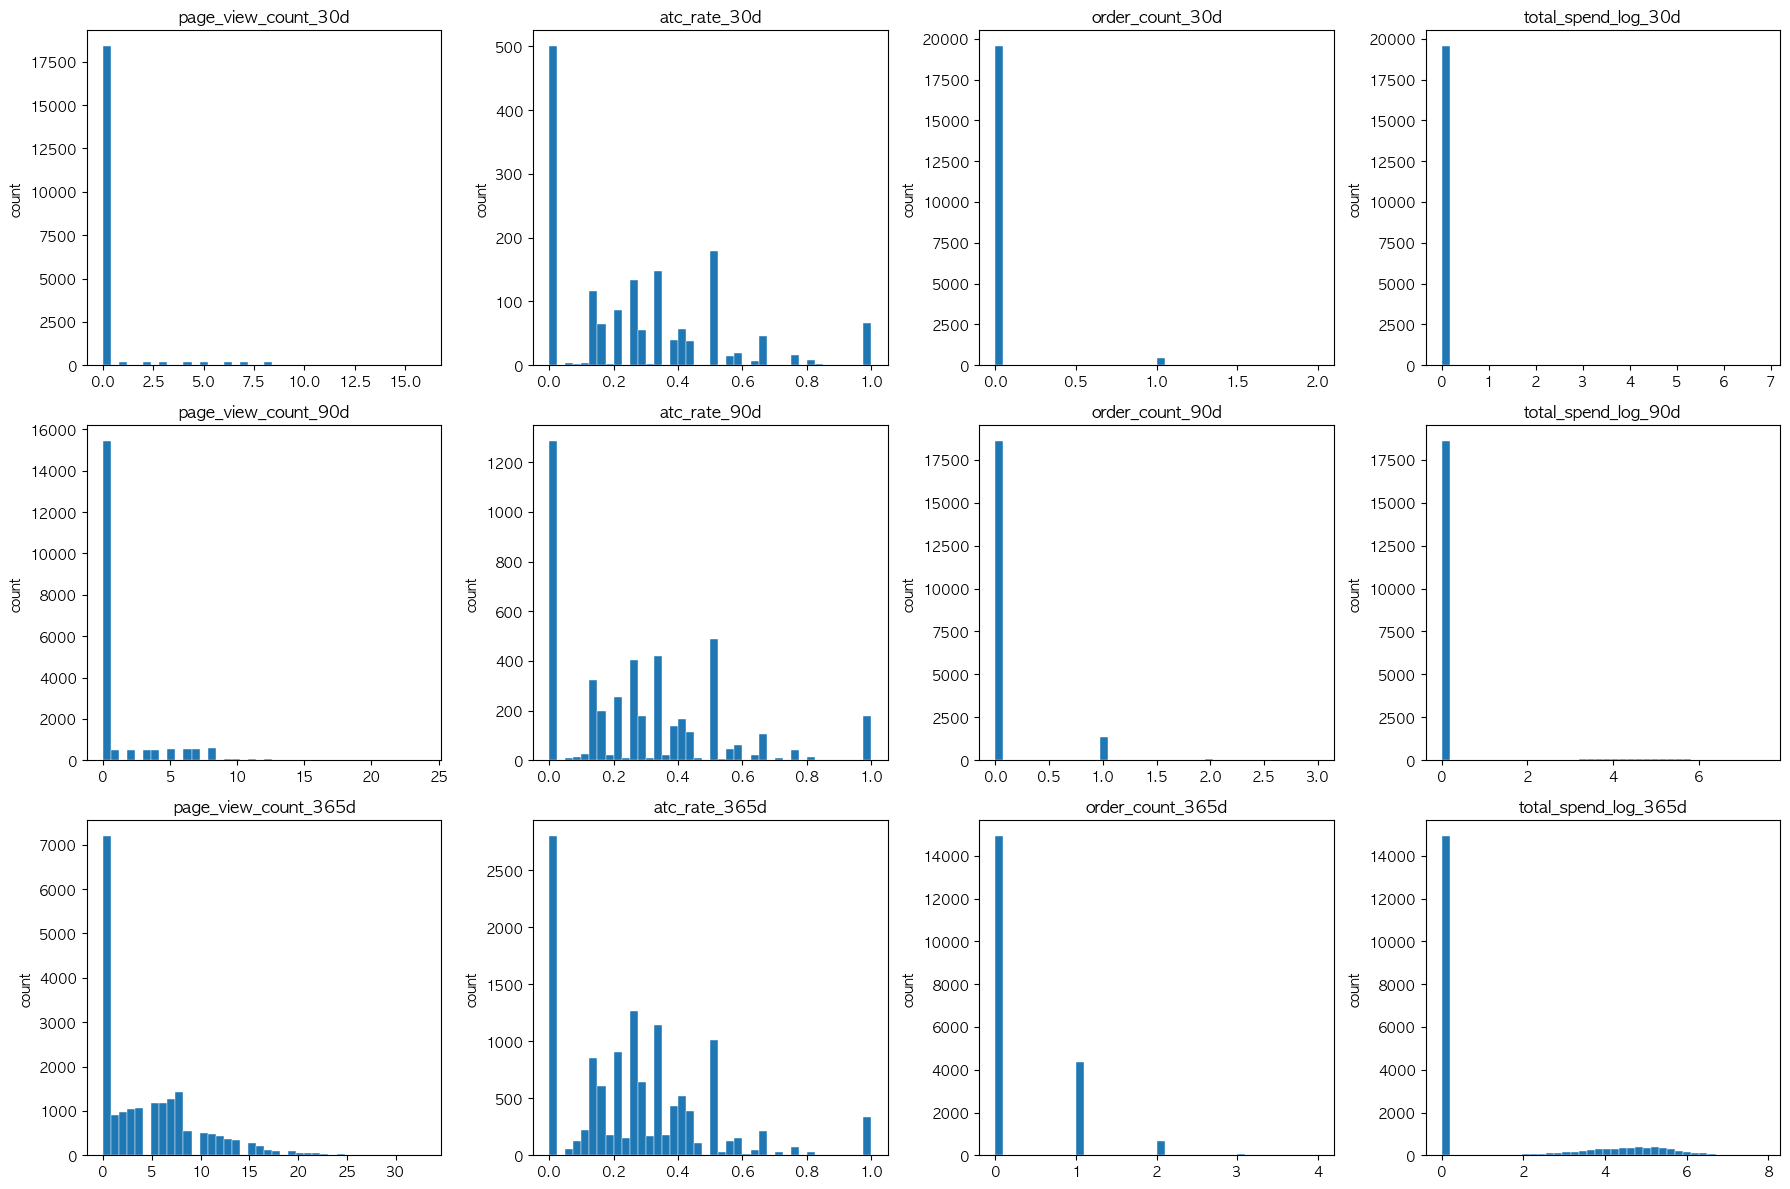

In [47]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
plot_cols = [
    "page_view_count_30d", "atc_rate_30d", "order_count_30d", "total_spend_log_30d",
    "page_view_count_90d", "atc_rate_90d", "order_count_90d", "total_spend_log_90d",
    "page_view_count_365d", "atc_rate_365d", "order_count_365d", "total_spend_log_365d",
]

for ax, col in zip(axes.flatten(), plot_cols):
    ax.hist(window_features_all[col].dropna(), bins=40, edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [48]:
window_compare_cols = [
    "page_view_count_30d", "atc_rate_30d", "order_count_30d", "total_spend_log_30d",
    "page_view_count_90d", "atc_rate_90d", "order_count_90d", "total_spend_log_90d",
    "page_view_count_365d", "atc_rate_365d", "order_count_365d", "total_spend_log_365d",
]

window_compare = pd.DataFrame({
    "all_mean": window_features_all[window_compare_cols].mean(),
    "us_mean": window_features_us[window_compare_cols].mean(),
})
window_compare["diff"] = window_compare["us_mean"] - window_compare["all_mean"]
display(window_compare)


,all_mean,us_mean,diff
page_view_count_30d,0.378200,0.390899,0.012699
atc_rate_30d,0.266306,0.275316,0.009010
order_count_30d,0.023700,0.024123,0.000423
total_spend_log_30d,0.104367,0.106545,0.002178
page_view_count_90d,1.171700,1.202851,0.031151
atc_rate_90d,0.270585,0.266351,-0.004234
order_count_90d,0.074450,0.078125,0.003675
total_spend_log_90d,0.320050,0.332662,0.012612
page_view_count_365d,4.640100,4.715186,0.075086
atc_rate_365d,0.265785,0.266886,0.001102
